In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
from src.data_loader import DataLoader

dataLoader = DataLoader()
dataLoader.download()
dataLoader.clean()
dataLoader.add_features()
dataLoader.add_technical_indicators()
sp500 = dataLoader.data

In [3]:
import pandas as pd

sp500.index = pd.to_datetime(sp500.index)
sp500 = sp500.loc["1990-01-01":].copy()
sp500 = sp500.dropna(subset=sp500.columns[sp500.columns != "Tomorrow"])

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from src.evaluate import backtest

model = KNeighborsClassifier(n_neighbors=5)

predictors = [
    # Technical indicators
    "EMA_9", "MACD", "MACD_Signal", "MACD_Histogram", "ATR_14",

    # Price action features
    "Close_Ratio_2", "Close_Ratio_5", "Close_Ratio_60", "Close_Ratio_250", "Close_Ratio_1000",
    "Volume_Ratio_2", "Volume_Ratio_5", "Volume_Ratio_60", "Volume_Ratio_250", "Volume_Ratio_1000",
    "Trend_2", "Trend_5", "Trend_60", "Trend_250", "Trend_1000",

    "Body_Pct", "Range_Pct"
]

predictions = backtest(sp500, model, predictors)


In [5]:
predictions

,Target,Predictions
Date,,
1999-11-22 00:00:00-05:00,0,0
1999-11-23 00:00:00-05:00,1,0
1999-11-24 00:00:00-05:00,0,0
1999-11-26 00:00:00-05:00,0,0
1999-11-29 00:00:00-05:00,0,0
...,...,...
2026-04-21 00:00:00-04:00,1,0
2026-04-22 00:00:00-04:00,0,0
2026-04-23 00:00:00-04:00,1,0


In [6]:
predictions["Predictions"].value_counts()

Predictions
0    3733
1    2913
Name: count, dtype: int64

In [7]:
from sklearn.metrics import precision_score

precision_score(predictions["Target"], predictions["Predictions"])

0.5320974939924477

In [8]:
from src.evaluate import add_returns, plot_equity_curve, plot_prediction_distribution, summary_metrics

predictions = add_returns(predictions, sp500)

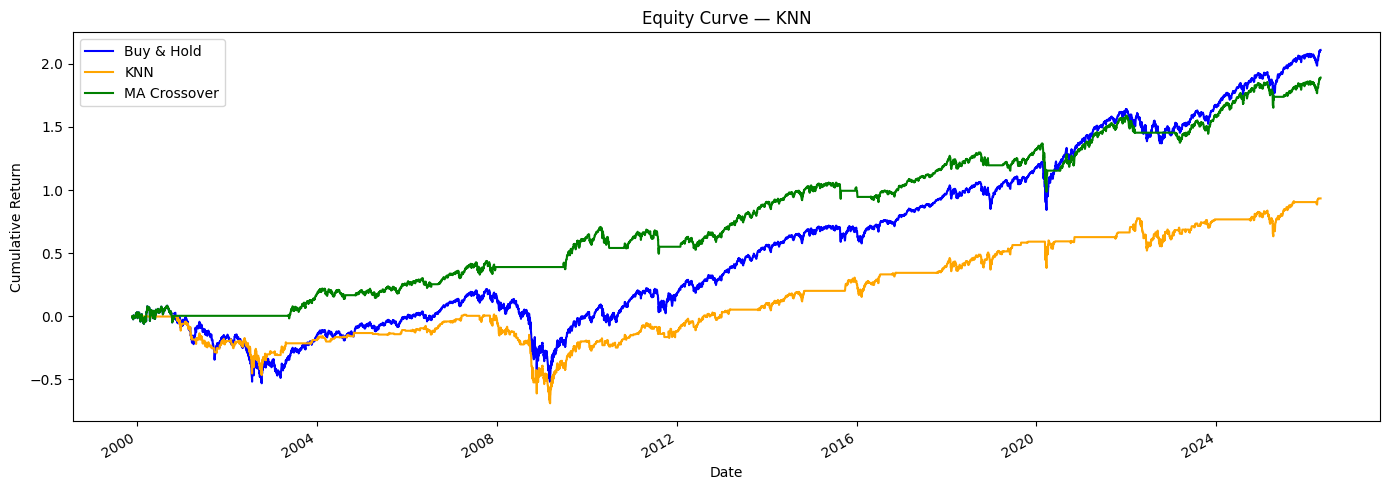

In [9]:
plot_equity_curve(predictions, "KNN", sp500)

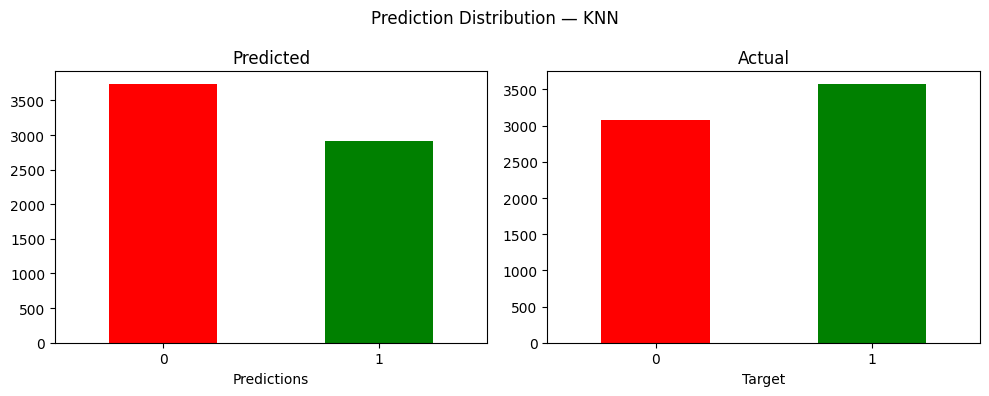

In [10]:
plot_prediction_distribution(predictions, "KNN")

In [11]:
summary_metrics(predictions, "KNN", sp500)

{'Model': 'KNN',
 'Precision': 0.5321,
 'Sharpe Ratio': 0.2485,
 'Strategy Return': 0.9343,
 'Buy & Hold Return': 2.1098,
 'MA Crossover Return': 1.8914,
 'Number of Trades': 2913}

In [12]:
import joblib

joblib.dump(predictions, '../models/predictions_knn.joblib')

['../models/predictions_knn.joblib']